<a href="https://colab.research.google.com/github/vaibhavjiyer87/engine-nvh-deep-learning/blob/main/notebooks/07_baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 1 — Mount Google Drive

# ============================================================
# CELL 1 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# Persistent project location in Google Drive
PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/01_EngineOperatingState"
)

if not PROJECT_DRIVE.exists():
    raise FileNotFoundError(
        f"Project folder was not found:\n{PROJECT_DRIVE}"
    )

print("Google Drive mounted successfully.")
print(f"Project Drive: {PROJECT_DRIVE}")

Mounted at /content/drive
Google Drive mounted successfully.
Project Drive: /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState


In [2]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 2 — Authenticate GitHub + determine Git author identity
# This assumes your GitHub token is stored in Colab Secrets under:
# GITHUB_TOKEN

# ============================================================
# CELL 2 — AUTHENTICATE GITHUB
# ============================================================

from google.colab import userdata

import os
import shutil
import subprocess


# ------------------------------------------------------------
# Repository settings
# ------------------------------------------------------------

REPOSITORY_NAME = "engine-nvh-deep-learning"


# ------------------------------------------------------------
# Load GitHub token securely from Colab Secrets
# ------------------------------------------------------------

github_token = userdata.get("GITHUB_TOKEN")

if not github_token:
    raise ValueError(
        "GITHUB_TOKEN was not found in Colab Secrets.\n"
        "Add the token and enable Notebook access."
    )

# GitHub CLI recognizes GH_TOKEN automatically.
os.environ["GH_TOKEN"] = github_token
os.environ["GH_HOST"] = "github.com"


# ------------------------------------------------------------
# Install GitHub CLI if necessary
# ------------------------------------------------------------

if shutil.which("gh") is None:

    print("Installing GitHub CLI...")

    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True,
    )

    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "gh",
        ],
        check=True,
    )


# ------------------------------------------------------------
# Verify authentication
# ------------------------------------------------------------

auth_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".login",
    ],
    capture_output=True,
    text=True,
)

if auth_result.returncode != 0:

    print(auth_result.stderr)

    raise RuntimeError(
        "GitHub authentication failed."
    )


GITHUB_USERNAME = auth_result.stdout.strip()

# ------------------------------------------------------------
# Configure Git commit identity
# ------------------------------------------------------------

user_id_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".id",
    ],
    capture_output=True,
    text=True,
    check=True,
)

GITHUB_USER_ID = (
    user_id_result.stdout.strip()
)

GIT_NAME = GITHUB_USERNAME

GIT_EMAIL = (
    f"{GITHUB_USER_ID}+"
    f"{GITHUB_USERNAME}@users.noreply.github.com"
)

print("Git identity prepared.")
print(f"Name:  {GIT_NAME}")
print(f"Email: {GIT_EMAIL}")

# ------------------------------------------------------------
# Configure Git to use GitHub CLI authentication
# ------------------------------------------------------------

subprocess.run(
    [
        "gh",
        "auth",
        "setup-git",
        "--hostname",
        "github.com",
        "--force",
    ],
    check=True,
)


print("GitHub authentication successful.")
print(f"GitHub user: {GITHUB_USERNAME}")
print(f"Repository:  {REPOSITORY_NAME}")

Git identity prepared.
Name:  vaibhavjiyer87
Email: 312107027+vaibhavjiyer87@users.noreply.github.com
GitHub authentication successful.
GitHub user: vaibhavjiyer87
Repository:  engine-nvh-deep-learning


In [3]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 3 — Clone repository if .git is missing / Update repository
# This cell deals with the temporary nature of /content.

# ============================================================
# CELL 3 — RESTORE LOCAL GITHUB REPOSITORY
# ============================================================

from pathlib import Path
import shutil
import subprocess


TEMP_REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

REPOSITORY_IDENTIFIER = (
    f"{GITHUB_USERNAME}/"
    f"{REPOSITORY_NAME}"
)


# ------------------------------------------------------------
# Case 1:
# Valid Git repository already exists
# ------------------------------------------------------------

if (
    TEMP_REPO_DIR.exists()
    and
    (TEMP_REPO_DIR / ".git").exists()
):

    print(
        "Git repository already exists "
        "in this Colab runtime."
    )

    # Pull updates only when the working tree is clean.
    status_result = subprocess.run(
        [
            "git",
            "-C",
            str(TEMP_REPO_DIR),
            "status",
            "--porcelain",
        ],
        capture_output=True,
        text=True,
        check=True,
    )

    if status_result.stdout.strip():

        print(
            "Local changes detected."
        )

        print(
            "Automatic git pull skipped "
            "to avoid overwriting local work."
        )

    else:

        print(
            "Working tree is clean. "
            "Updating from GitHub..."
        )

        pull_result = subprocess.run(
            [
                "git",
                "-C",
                str(TEMP_REPO_DIR),
                "pull",
                "--ff-only",
            ],
            capture_output=True,
            text=True,
        )

        print(pull_result.stdout)

        if pull_result.returncode != 0:
            print(pull_result.stderr)


# ------------------------------------------------------------
# Case 2:
# Folder exists, but it is NOT a Git repository
# ------------------------------------------------------------

elif TEMP_REPO_DIR.exists():

    raise RuntimeError(
        f"The folder exists but is not a Git repository:\n"
        f"{TEMP_REPO_DIR}\n\n"
        "Do not run git init. Inspect or back up the folder "
        "before removing it and rerunning this cell."
    )


# ------------------------------------------------------------
# Case 3:
# Fresh runtime — clone repository
# ------------------------------------------------------------

else:

    print(
        "Repository not present in this runtime."
    )

    print(
        f"Cloning {REPOSITORY_IDENTIFIER}..."
    )

    clone_result = subprocess.run(
        [
            "gh",
            "repo",
            "clone",
            REPOSITORY_IDENTIFIER,
            str(TEMP_REPO_DIR),
        ],
        capture_output=True,
        text=True,
    )

    print(clone_result.stdout)

    if clone_result.returncode != 0:

        print(clone_result.stderr)

        raise RuntimeError(
            "Repository clone failed."
        )


# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

if not (
    TEMP_REPO_DIR
    / ".git"
).exists():

    raise RuntimeError(
        "Repository restoration failed."
    )


print("Local Git repository is ready.")
print(f"Location: {TEMP_REPO_DIR}")

Repository not present in this runtime.
Cloning vaibhavjiyer87/engine-nvh-deep-learning...

Local Git repository is ready.
Location: /content/engine-nvh-deep-learning


In [4]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 4 — Define REPO_DIR and all standard paths + restore requirements

# ============================================================
# CELL 4 — DEFINE PROJECT PATHS
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# GitHub working repository
# ------------------------------------------------------------

REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

if not (
    REPO_DIR
    / ".git"
).exists():

    raise FileNotFoundError(
        f"Valid Git repository not found at:\n"
        f"{REPO_DIR}\n\n"
        "Run Cell 3 first."
    )


# ------------------------------------------------------------
# Persistent raw dataset
# ------------------------------------------------------------

RAW_ROOT = (
    PROJECT_DRIVE
    / "data"
    / "raw"
    / "procedural_engine_sounds"
)

DATASET_ROOT = (
    RAW_ROOT
    / "dataset"
)

AUDIO_DIR = (
    DATASET_ROOT
    / "audio"
    / "A_full_set"
)


# ------------------------------------------------------------
# Persistent Google Drive manifests
# ------------------------------------------------------------

DRIVE_MANIFEST_DIR = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
)


# ------------------------------------------------------------
# GitHub configuration
# ------------------------------------------------------------

CONFIG_DIR = (
    REPO_DIR
    / "configs"
)

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

SPLIT_DIR = (
    REPO_DIR
    / "data"
    / "splits"
)


# ------------------------------------------------------------
# GitHub result directories
# ------------------------------------------------------------

RESULTS_DIR = (
    REPO_DIR
    / "results"
)

FIGURE_DIR = (
    RESULTS_DIR
    / "figures"
)

TABLE_DIR = (
    RESULTS_DIR
    / "tables"
)

DATA_AUDIT_FIGURE_DIR = (
    FIGURE_DIR
    / "data_audit"
)

DESIGN_FIGURE_DIR = (
    FIGURE_DIR
    / "preprocessing_design"
)

SPLIT_FIGURE_DIR = (
    FIGURE_DIR
    / "split_design"
)


# ------------------------------------------------------------
# Persistent Drive output directories
# ------------------------------------------------------------

DRIVE_OUTPUT_DIR = (
    PROJECT_DRIVE
    / "outputs"
)

DRIVE_DESIGN_TABLE_DIR = (
    DRIVE_OUTPUT_DIR
    / "tables"
    / "preprocessing_design"
)


# ------------------------------------------------------------
# Create output folders if missing
# ------------------------------------------------------------

directories_to_create = [
    CONFIG_DIR,
    REPORT_DIR,
    SPLIT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    DATA_AUDIT_FIGURE_DIR,
    DESIGN_FIGURE_DIR,
    SPLIT_FIGURE_DIR,
    DRIVE_DESIGN_TABLE_DIR,
]

for directory in directories_to_create:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("Project paths restored.")
print()
print(f"REPO_DIR:     {REPO_DIR}")
print(f"PROJECT_DRIVE:{PROJECT_DRIVE}")
print(f"RAW_ROOT:     {RAW_ROOT}")
print(f"AUDIO_DIR:    {AUDIO_DIR}")

# ------------------------------------------------------------
# Apply Git commit identity to cloned repository
# ------------------------------------------------------------

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.name",
        GIT_NAME,
    ],
    check=True,
)

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.email",
        GIT_EMAIL,
    ],
    check=True,
)

print("Git commit identity applied to repository.")

# ------------------------------------------------------------
# Restore project Python dependencies
# ------------------------------------------------------------

import subprocess

REQUIREMENTS_PATH = (
    REPO_DIR
    / "requirements.txt"
)

if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(
        f"requirements.txt not found:\n"
        f"{REQUIREMENTS_PATH}"
    )

install_result = subprocess.run(
    [
        "python",
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(REQUIREMENTS_PATH),
    ],
    capture_output=True,
    text=True,
)

if install_result.returncode != 0:

    print(install_result.stdout)
    print(install_result.stderr)

    raise RuntimeError(
        "Project dependency installation failed."
    )

print(
    "Project Python dependencies restored."
)

Project paths restored.

REPO_DIR:     /content/engine-nvh-deep-learning
PROJECT_DRIVE:/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState
RAW_ROOT:     /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds
AUDIO_DIR:    /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds/dataset/audio/A_full_set
Git commit identity applied to repository.
Project Python dependencies restored.


In [9]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 5 — Load persistent analysis data
# This cell restores the major tables you've created so far.
# This is conditional, as some files may not exist yet depending on
# where you are in the project.

# ============================================================
# CELL 5 — LOAD PERSISTENT ANALYSIS DATA
# ============================================================

# ============================================================
# STANDARD PROJECT IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import yaml

from tqdm.auto import tqdm

print(
    "Standard project libraries imported."
)


# ------------------------------------------------------------
# 1. Raw-file manifest — REQUIRED
# ------------------------------------------------------------

RAW_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "raw_file_manifest_v001.csv"
)

if not RAW_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Required raw manifest not found:\n"
        f"{RAW_MANIFEST_PATH}"
    )


raw_manifest = pd.read_csv(
    RAW_MANIFEST_PATH
)

print(
    f"LOADED raw_manifest: "
    f"{raw_manifest.shape}"
)


# ------------------------------------------------------------
# 2. PREP-001 detailed target analysis — OPTIONAL
# ------------------------------------------------------------

PREP001_TARGET_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "prep001_target_analysis_v001.csv.gz"
)

if PREP001_TARGET_PATH.exists():

    prep001_targets = pd.read_csv(
        PREP001_TARGET_PATH
    )

    print(
        f"LOADED prep001_targets: "
        f"{prep001_targets.shape}"
    )

else:

    prep001_targets = None

    print(
        "NOT FOUND: prep001 target analysis "
        "(this is okay if it has not been generated yet)."
    )


# ------------------------------------------------------------
# 3. Window candidate metrics — OPTIONAL
# ------------------------------------------------------------

WINDOW_CANDIDATE_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "window_candidate_metrics_v001.csv.gz"
)

if WINDOW_CANDIDATE_PATH.exists():

    window_candidates = pd.read_csv(
        WINDOW_CANDIDATE_PATH
    )

    print(
        f"LOADED window_candidates: "
        f"{window_candidates.shape}"
    )

else:

    window_candidates = None

    print(
        "NOT FOUND: window candidate metrics."
    )


# ------------------------------------------------------------
# 4. Frozen SPLIT-001 file assignment — OPTIONAL
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if FILE_SPLIT_PATH.exists():

    file_split = pd.read_csv(
        FILE_SPLIT_PATH
    )

    print(
        f"LOADED file_split: "
        f"{file_split.shape}"
    )

else:

    file_split = None

    print(
        "NOT FOUND: SPLIT-001 file assignment."
    )


# ============================================================
# LOAD REQUIRED FROZEN PROJECT SPECIFICATIONS
# ============================================================

import yaml


# ------------------------------------------------------------
# PREP-001 — REQUIRED
# ------------------------------------------------------------

PREPROCESSING_CONFIG_PATH = (
    CONFIG_DIR
    / "preprocessing_v001.yaml"
)

if not PREPROCESSING_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required PREP-001 configuration is missing:\n"
        f"{PREPROCESSING_CONFIG_PATH}"
    )


try:

    with open(
        PREPROCESSING_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        preprocessing_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "PREP-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
    != "PREP-001"
):

    raise RuntimeError(
        "Unexpected preprocessing version."
    )


print(
    "LOADED preprocessing_config: PREP-001"
)


# ------------------------------------------------------------
# SPLIT-001 — REQUIRED
# ------------------------------------------------------------

SPLIT_CONFIG_PATH = (
    CONFIG_DIR
    / "split_v001.yaml"
)

if not SPLIT_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 configuration is missing:\n"
        f"{SPLIT_CONFIG_PATH}"
    )


try:

    with open(
        SPLIT_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        split_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "SPLIT-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    split_config[
        "specification"
    ]["split_version"]
    != "SPLIT-001"
):

    raise RuntimeError(
        "Unexpected split version."
    )


print(
    "LOADED split_config: SPLIT-001"
)


# ------------------------------------------------------------
# FILE SPLIT — REQUIRED
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if not FILE_SPLIT_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 assignment file is missing:\n"
        f"{FILE_SPLIT_PATH}"
    )


file_split = pd.read_csv(
    FILE_SPLIT_PATH
)

print(
    f"LOADED file_split: "
    f"{file_split.shape}"
)


# ============================================================
# DERIVE FROZEN RUNTIME CONSTANTS
# ============================================================

# ------------------------------------------------------------
# PREP-001 identity
# ------------------------------------------------------------

PREPROCESSING_VERSION = (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
)

DATASET_SUBSET = (
    preprocessing_config[
        "specification"
    ]["dataset_subset"]
)


# ------------------------------------------------------------
# Windowing
# ------------------------------------------------------------

WINDOW_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["window_duration_s"]
)

OVERLAP_FRACTION = float(
    preprocessing_config[
        "windowing"
    ]["overlap_fraction"]
)

HOP_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["hop_duration_s"]
)


# ------------------------------------------------------------
# Source-data definition
# ------------------------------------------------------------

SOURCE_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "source_data"
    ]["source_sample_rate_hz"]
)

EXPECTED_CHANNELS = int(
    preprocessing_config[
        "source_data"
    ]["expected_channels"]
)

RPM_SCALE_FACTOR = float(
    preprocessing_config[
        "source_data"
    ]["rpm_scale_factor"]
)

TORQUE_SCALE_FACTOR_NM = float(
    preprocessing_config[
        "source_data"
    ]["torque_scale_factor_nm"]
)


# ------------------------------------------------------------
# YAML channel numbers are human-readable 1-based numbers.
# NumPy arrays use 0-based indexing.
# ------------------------------------------------------------

RPM_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["rpm"]
    )
    - 1
)

TORQUE_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["torque"]
    )
    - 1
)


# ------------------------------------------------------------
# Audio processing
# ------------------------------------------------------------

TARGET_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "audio_processing"
    ]["target_sample_rate_hz"]
)

AUDIO_CHANNEL_STRATEGY = (
    preprocessing_config[
        "audio_processing"
    ]["channel_strategy"]
)


# ------------------------------------------------------------
# Steady-state criterion
# ------------------------------------------------------------

ABSOLUTE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_absolute_range_rpm"
    ]
)

RELATIVE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_relative_range_fraction"
    ]
)


# ------------------------------------------------------------
# SPLIT-001 identity
# ------------------------------------------------------------

SPLIT_VERSION = (
    split_config[
        "specification"
    ]["split_version"]
)


print("Frozen runtime constants restored.")
print()
print(f"Preprocessing:       {PREPROCESSING_VERSION}")
print(f"Split:               {SPLIT_VERSION}")
print(f"Dataset subset:      {DATASET_SUBSET}")
print(f"Window duration:     {WINDOW_DURATION_S} s")
print(f"Overlap:             {100 * OVERLAP_FRACTION:.0f}%")
print(f"Source sample rate:  {SOURCE_SAMPLE_RATE_HZ} Hz")
print(f"Target sample rate:  {TARGET_SAMPLE_RATE_HZ} Hz")
print(f"Expected channels:   {EXPECTED_CHANNELS}")
print(f"RPM channel index:   {RPM_CHANNEL_INDEX}")
print(f"Torque channel idx:  {TORQUE_CHANNEL_INDEX}")
print(f"Channel strategy:    {AUDIO_CHANNEL_STRATEGY}")

# ============================================================
# VALIDATE FROZEN RUNTIME CONSTANTS
# ============================================================

assert PREPROCESSING_VERSION == "PREP-001", (
    f"Expected PREP-001, found {PREPROCESSING_VERSION}"
)

assert SPLIT_VERSION == "SPLIT-001", (
    f"Expected SPLIT-001, found {SPLIT_VERSION}"
)

assert SOURCE_SAMPLE_RATE_HZ == 48000, (
    "Unexpected PREP-001 source sample rate."
)

assert TARGET_SAMPLE_RATE_HZ == 16000, (
    "Unexpected PREP-001 target sample rate."
)

assert EXPECTED_CHANNELS == 4, (
    "Unexpected PREP-001 channel count."
)

assert WINDOW_DURATION_S > 0

assert 0 <= OVERLAP_FRACTION < 1

assert RPM_CHANNEL_INDEX < EXPECTED_CHANNELS

assert TORQUE_CHANNEL_INDEX < EXPECTED_CHANNELS

assert file_split["file_id"].is_unique

assert set(
    file_split["split"].unique()
) == {
    "train",
    "validation",
    "test",
}

print(
    "PASS: Frozen runtime constants validated."
)

# ============================================================
# LOAD SAMPLE-MANIFEST-001
# ============================================================

SAMPLE_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "sample_manifest_v001.csv"
)

if not SAMPLE_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        "Required SAMPLE-MANIFEST-001 "
        "is missing:\n"
        f"{SAMPLE_MANIFEST_PATH}"
    )


sample_manifest = pd.read_csv(
    SAMPLE_MANIFEST_PATH
)


assert (
    sample_manifest[
        "sample_id"
    ].is_unique
)

assert set(
    sample_manifest[
        "preprocessing_version"
    ]
) == {
    "PREP-001"
}

assert set(
    sample_manifest[
        "split_version"
    ]
) == {
    "SPLIT-001"
}


print(
    f"LOADED sample_manifest: "
    f"{sample_manifest.shape}"
)

# ============================================================
# PROJECT SESSION READINESS SUMMARY
# ============================================================

print()
print("=" * 64)
print("NVH DEEP-LEARNING PROJECT SESSION READY")
print("=" * 64)

print(
    f"Raw manifest:       "
    f"{len(raw_manifest):,} source files"
)

print(
    f"Preprocessing:      "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Dataset split:      "
    f"{SPLIT_VERSION}"
)

print(
    f"Window:             "
    f"{WINDOW_DURATION_S:.1f} s"
)

print(
    f"Overlap:            "
    f"{100 * OVERLAP_FRACTION:.0f}%"
)

print(
    f"Source sample rate: "
    f"{SOURCE_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Model sample rate:  "
    f"{TARGET_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Audio strategy:     "
    f"{AUDIO_CHANNEL_STRATEGY}"
)

print()
print("SPLIT-001:")

print(
    file_split[
        "split"
    ]
    .value_counts()
    .to_string()
)

if (
    "sample_manifest" in globals()
    and
    sample_manifest is not None
):

    print()
    print(
        f"Sample manifest:    "
        f"{len(sample_manifest):,} samples"
    )

else:

    print()
    print(
        "Sample manifest:    "
        "not generated yet"
    )

print("=" * 64)

print(
    f"Sample manifest:    "
    f"{len(sample_manifest):,} samples"
)

# ============================================================
# LOAD ORDER-001 (added after initiating 06_bseline_feature_generation.ipynb)
# ============================================================

ORDER_CONFIG_PATH = (
    CONFIG_DIR
    / "order_analysis_v001.yaml"
)

if not ORDER_CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"ORDER-001 configuration not found:\n"
        f"{ORDER_CONFIG_PATH}"
    )

with open(
    ORDER_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    order_analysis_config = yaml.safe_load(file)

ORDER_ANALYSIS_VERSION = (
    order_analysis_config[
        "specification"
    ]["order_analysis_version"]
)

assert ORDER_ANALYSIS_VERSION == "ORDER-001"

print(
    "PASS: ORDER-001 loaded."
)

# ============================================================
# LOAD FEAT-001 — REQUIRED FROM NOTEBOOK 07 ONWARD
# ============================================================

FEATURE_CONFIG_PATH = (
    CONFIG_DIR
    / "features_v001.yaml"
)

if not FEATURE_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "Required FEAT-001 configuration "
        "is missing:\n"
        f"{FEATURE_CONFIG_PATH}"
    )


try:

    with open(
        FEATURE_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        feature_config = yaml.safe_load(
            file
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "FEAT-001 exists but is invalid YAML.\n"
        f"{error}"
    )


FEATURE_VERSION = (
    feature_config[
        "specification"
    ]["feature_version"]
)

assert FEATURE_VERSION == "FEAT-001", (
    f"Expected FEAT-001, "
    f"found {FEATURE_VERSION}"
)


# ------------------------------------------------------------
# Load persistent FEAT-001 feature table
# ------------------------------------------------------------

BASELINE_FEATURE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "FEAT-001"
    / "baseline_features_v001.parquet"
)

if not BASELINE_FEATURE_PATH.exists():

    raise FileNotFoundError(
        "Required FEAT-001 feature table "
        "is missing:\n"
        f"{BASELINE_FEATURE_PATH}"
    )


baseline_features = pd.read_parquet(
    BASELINE_FEATURE_PATH
)


# ------------------------------------------------------------
# Validate frozen feature table
# ------------------------------------------------------------

assert (
    baseline_features[
        "sample_id"
    ].is_unique
)

assert (
    baseline_features[
        "sample_id"
    ].notna().all()
)

assert set(
    baseline_features[
        "feature_version"
    ].unique()
) == {
    "FEAT-001"
}

assert set(
    baseline_features[
        "split"
    ].unique()
) == {
    "train",
    "validation",
    "test",
}

assert (
    len(baseline_features)
    ==
    len(sample_manifest)
)

assert set(
    baseline_features[
        "sample_id"
    ]
) == set(
    sample_manifest[
        "sample_id"
    ]
)


print(
    f"LOADED baseline_features: "
    f"{baseline_features.shape}"
)

print(
    f"Feature version: "
    f"{FEATURE_VERSION}"
)

print(
    "PASS: FEAT-001 restored and validated."
)

# ------------------------------------------------------------
# Updating Readiness Summary
# ------------------------------------------------------------
print()
print("=" * 68)
print("MODELING ENVIRONMENT READY")
print("=" * 68)

print(
    f"Preprocessing:       "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Dataset split:       "
    f"{SPLIT_VERSION}"
)

print(
    f"Order analysis:      "
    f"{ORDER_ANALYSIS_VERSION}"
)

print(
    f"Feature definition:  "
    f"{FEATURE_VERSION}"
)

print(
    f"Sample manifest:     "
    f"{len(sample_manifest):,} samples"
)

print(
    f"Feature table:       "
    f"{len(baseline_features):,} samples"
)

print(
    f"Feature columns:     "
    f"{baseline_features.shape[1]}"
)

print("=" * 68)

Standard project libraries imported.
LOADED raw_manifest: (767, 21)
LOADED prep001_targets: (16503, 23)
LOADED window_candidates: (58653, 16)
LOADED file_split: (767, 11)
LOADED preprocessing_config: PREP-001
LOADED split_config: SPLIT-001
LOADED file_split: (767, 11)
Frozen runtime constants restored.

Preprocessing:       PREP-001
Split:               SPLIT-001
Dataset subset:      A_full_set
Window duration:     1.0 s
Overlap:             50%
Source sample rate:  48000 Hz
Target sample rate:  16000 Hz
Expected channels:   4
RPM channel index:   2
Torque channel idx:  3
Channel strategy:    mono_average
PASS: Frozen runtime constants validated.
LOADED sample_manifest: (16503, 34)

NVH DEEP-LEARNING PROJECT SESSION READY
Raw manifest:       767 source files
Preprocessing:      PREP-001
Dataset split:      SPLIT-001
Window:             1.0 s
Overlap:            50%
Source sample rate: 48,000 Hz
Model sample rate:  16,000 Hz
Audio strategy:     mono_average

SPLIT-001:
split
train      

The notebook follows this sequence:

* Step 0   Run Startup Cells 1–5
* Step 1   Verify full modeling lineage
* Step 2   Build leakage-safe modeling population
* Step 3   Define predictor/target columns
* Step 4   Audit train/validation/test distributions
* Step 5   BASE-001 — Ridge Regression
* Step 6   BASE-002 — Random Forest
* Step 7   Compare baselines on validation only
* Step 8   Freeze preferred baseline and evaluate test once
* Step 9   Error analysis and engineering plots
* Step 10  Save models/predictions/results
* Step 11  Update experiment_summary.csv
* Step 12  Document + GitHub closeout

In [10]:
# ============================================================
# STEP 1 — VERIFY COMPLETE MODELING LINEAGE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import joblib

from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


required_objects = [
    "baseline_features",
    "sample_manifest",
    "preprocessing_config",
    "split_config",
    "order_analysis_config",
    "feature_config",
    "PREPROCESSING_VERSION",
    "SPLIT_VERSION",
    "ORDER_ANALYSIS_VERSION",
    "FEATURE_VERSION",
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:

    raise RuntimeError(
        "Missing required modeling objects:\n"
        +
        "\n".join(
            f" - {name}"
            for name in missing
        )
        +
        "\n\nRun the current Startup Cells 1–5."
    )


assert PREPROCESSING_VERSION == "PREP-001"
assert SPLIT_VERSION == "SPLIT-001"
assert ORDER_ANALYSIS_VERSION == "ORDER-001"
assert FEATURE_VERSION == "FEAT-001"

assert (
    baseline_features[
        "sample_id"
    ].is_unique
)

assert set(
    baseline_features[
        "split"
    ].unique()
) == {
    "train",
    "validation",
    "test",
}


print("=" * 65)
print("MODEL LINEAGE VERIFIED")
print("=" * 65)

print(
    f"PREP:     "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"SPLIT:    "
    f"{SPLIT_VERSION}"
)

print(
    f"ORDER:    "
    f"{ORDER_ANALYSIS_VERSION}"
)

print(
    f"FEATURES: "
    f"{FEATURE_VERSION}"
)

print(
    f"Rows:     "
    f"{len(baseline_features):,}"
)

print("=" * 65)

MODEL LINEAGE VERIFIED
PREP:     PREP-001
SPLIT:    SPLIT-001
ORDER:    ORDER-001
FEATURES: FEAT-001
Rows:     16,503


In [11]:
# Create model output locations:

BASELINE_MODEL_FIGURE_DIR = (
    FIGURE_DIR
    / "baseline_models"
)

BASELINE_MODEL_TABLE_DIR = (
    TABLE_DIR
    / "baseline_models"
)

DRIVE_MODEL_DIR = (
    PROJECT_DRIVE
    / "models"
    / "baseline"
)

for directory in [
    BASELINE_MODEL_FIGURE_DIR,
    BASELINE_MODEL_TABLE_DIR,
    DRIVE_MODEL_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(
    "PASS: Baseline model "
    "output directories ready."
)

PASS: Baseline model output directories ready.


In [12]:
# Step 2 — Build the RPM modeling population
# For the first RPM models, retaining only
# PREP-001 steady-state windows:

# ============================================================
# STEP 2 — BUILD RPM MODELING POPULATION
# ============================================================

rpm_model_data = (
    baseline_features.loc[
        baseline_features[
            "model_eligible_rpm_v001"
        ] == True
    ]
    .copy()
)

print(
    f"Total FEAT-001 rows: "
    f"{len(baseline_features):,}"
)

print(
    f"Steady RPM-model rows: "
    f"{len(rpm_model_data):,}"
)

print("\nSamples by split:")

display(
    rpm_model_data[
        "split"
    ]
    .value_counts()
    .rename("sample_count")
)

Total FEAT-001 rows: 16,503
Steady RPM-model rows: 11,646

Samples by split:


,sample_count
split,
train,7958
test,1890
validation,1798


In [13]:
#.. validate
assert set(
    rpm_model_data[
        "split"
    ].unique()
) == {
    "train",
    "validation",
    "test",
}

assert (
    rpm_model_data[
        "rpm_mean"
    ].notna().all()
)

print(
    "PASS: RPM modeling population valid."
)

PASS: RPM modeling population valid.


In [14]:
# Step 3 — Define predictors and target

# ============================================================
# STEP 3 — DEFINE PREDICTORS AND TARGET
# ============================================================

NON_FEATURE_COLUMNS = [
    "sample_id",
    "parent_file_id",
    "split",
    "operating_state",
    "model_eligible_rpm_v001",
    "rpm_mean",
    "torque_mean_nm",
    "preprocessing_version",
    "split_version",
    "feature_version",
]

FEATURE_COLUMNS = [
    column
    for column in rpm_model_data.columns
    if column not in NON_FEATURE_COLUMNS
]

TARGET_COLUMN = "rpm_mean"

print(
    f"Number of predictors: "
    f"{len(FEATURE_COLUMNS)}"
)

print(
    f"Target: "
    f"{TARGET_COLUMN}"
)

print("\nPredictors:")

for feature in FEATURE_COLUMNS:
    print(
        " -",
        feature,
    )

Number of predictors: 41
Target: rpm_mean

Predictors:
 - rms
 - peak_abs
 - crest_factor
 - zero_crossing_rate
 - spectral_centroid_hz
 - spectral_bandwidth_hz
 - spectral_rolloff_85_hz
 - spectral_flatness
 - dominant_frequency_hz
 - band_energy_0_250_hz
 - band_energy_250_500_hz
 - band_energy_500_1000_hz
 - band_energy_1000_2000_hz
 - band_energy_2000_4000_hz
 - band_energy_4000_8000_hz
 - mfcc_01_mean
 - mfcc_01_std
 - mfcc_02_mean
 - mfcc_02_std
 - mfcc_03_mean
 - mfcc_03_std
 - mfcc_04_mean
 - mfcc_04_std
 - mfcc_05_mean
 - mfcc_05_std
 - mfcc_06_mean
 - mfcc_06_std
 - mfcc_07_mean
 - mfcc_07_std
 - mfcc_08_mean
 - mfcc_08_std
 - mfcc_09_mean
 - mfcc_09_std
 - mfcc_10_mean
 - mfcc_10_std
 - mfcc_11_mean
 - mfcc_11_std
 - mfcc_12_mean
 - mfcc_12_std
 - mfcc_13_mean
 - mfcc_13_std


In [15]:
# Step 3B — Explicit target-leakage audit
# This is especially important bcoz ORDER-001 used RPM for physics validation.
# Those RPM-dependent order features are intentionally not in FEAT-001.

# ============================================================
# TARGET-LEAKAGE AUDIT
# ============================================================

forbidden_exact_columns = [
    "rpm_mean",
    "rpm_median",
    "rpm_min",
    "rpm_max",
    "rpm_std",
    "rpm_range",
    "torque_mean_nm",
    "sample_id",
    "parent_file_id",
    "split",
]

leakage_found = [
    column
    for column in forbidden_exact_columns
    if column in FEATURE_COLUMNS
]

if leakage_found:

    raise RuntimeError(
        "Target/metadata leakage detected:\n"
        +
        "\n".join(
            f" - {column}"
            for column in leakage_found
        )
    )


# Also flag suspicious RPM-named predictors.
suspicious_rpm_features = [
    column
    for column in FEATURE_COLUMNS
    if "rpm" in column.lower()
]

if suspicious_rpm_features:

    raise RuntimeError(
        "Potential RPM-derived feature leakage:\n"
        +
        "\n".join(
            f" - {column}"
            for column
            in suspicious_rpm_features
        )
    )


print(
    "PASS: No RPM target or metadata "
    "leakage detected."
)

PASS: No RPM target or metadata leakage detected.


In [16]:
# Step 3C — Construct train/validation/test matrices

train_df = (
    rpm_model_data.loc[
        rpm_model_data[
            "split"
        ] == "train"
    ]
    .copy()
)

validation_df = (
    rpm_model_data.loc[
        rpm_model_data[
            "split"
        ] == "validation"
    ]
    .copy()
)

test_df = (
    rpm_model_data.loc[
        rpm_model_data[
            "split"
        ] == "test"
    ]
    .copy()
)


X_train = (
    train_df[
        FEATURE_COLUMNS
    ]
)

y_train = (
    train_df[
        TARGET_COLUMN
    ]
)


X_validation = (
    validation_df[
        FEATURE_COLUMNS
    ]
)

y_validation = (
    validation_df[
        TARGET_COLUMN
    ]
)


X_test = (
    test_df[
        FEATURE_COLUMNS
    ]
)

y_test = (
    test_df[
        TARGET_COLUMN
    ]
)


print(
    "Train:      ",
    X_train.shape,
)

print(
    "Validation: ",
    X_validation.shape,
)

print(
    "Test:       ",
    X_test.shape,
)

Train:       (7958, 41)
Validation:  (1798, 41)
Test:        (1890, 41)


,count,min,median,mean,max,std
split,,,,,,
test,1890,0.0,2855.641810,3197.334094,7007.446289,1749.410125
train,7958,0.0,2693.511422,3010.708427,6992.082799,1742.070618
validation,1798,0.0,2920.069141,3095.391306,6908.600909,1663.470357


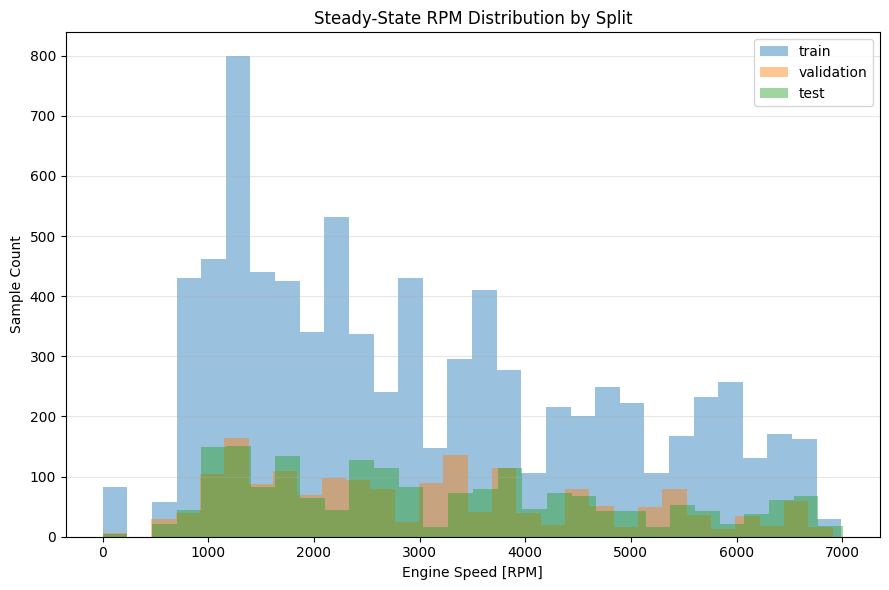

In [18]:
# Step 4 — Audit RPM distribution after steady-state filtering

# ============================================================
# STEP 4 — TARGET DISTRIBUTION AUDIT
# ============================================================

target_summary = (
    rpm_model_data
    .groupby(
        "split"
    )["rpm_mean"]
    .agg(
        [
            "count",
            "min",
            "median",
            "mean",
            "max",
            "std",
        ]
    )
)

display(
    target_summary
)

# ..Plot
fig, ax = plt.subplots(
    figsize=(9, 6)
)

for split_name in [
    "train",
    "validation",
    "test",
]:

    values = (
        rpm_model_data.loc[
            rpm_model_data[
                "split"
            ] == split_name,
            "rpm_mean",
        ]
    )

    ax.hist(
        values,
        bins=30,
        alpha=0.45,
        label=split_name,
    )

ax.set_title(
    "Steady-State RPM Distribution by Split"
)

ax.set_xlabel(
    "Engine Speed [RPM]"
)

ax.set_ylabel(
    "Sample Count"
)

ax.legend()

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

fig.savefig(
    BASELINE_MODEL_FIGURE_DIR
    / "01_rpm_target_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

In [19]:
# Step 5 — Define common regression metrics

# ============================================================
# STEP 5 — REGRESSION METRICS
# ============================================================

def calculate_regression_metrics(
    y_true,
    y_pred,
):

    y_true_array = np.asarray(
        y_true
    )

    y_pred_array = np.asarray(
        y_pred
    )

    absolute_error = np.abs(
        y_true_array
        - y_pred_array
    )

    return {

        "mae_rpm":
            float(
                mean_absolute_error(
                    y_true_array,
                    y_pred_array,
                )
            ),

        "rmse_rpm":
            float(
                np.sqrt(
                    mean_squared_error(
                        y_true_array,
                        y_pred_array,
                    )
                )
            ),

        "r2":
            float(
                r2_score(
                    y_true_array,
                    y_pred_array,
                )
            ),

        "p95_absolute_error_rpm":
            float(
                np.percentile(
                    absolute_error,
                    95,
                )
            ),
    }

In [20]:
# Step 6 — BASE-001: Ridge Regression
# Use a Pipeline; that guarantees StandardScaler sees only training data.

# ============================================================
# STEP 6 — BASE-001 RIDGE REGRESSION
# ============================================================

RIDGE_ALPHAS = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
]

ridge_validation_records = []
ridge_models = {}


for alpha in RIDGE_ALPHAS:

    ridge_pipeline = Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),

            (
                "ridge",
                Ridge(
                    alpha=alpha,
                ),
            ),
        ]
    )

    ridge_pipeline.fit(
        X_train,
        y_train,
    )

    validation_pred = (
        ridge_pipeline.predict(
            X_validation
        )
    )

    metrics = (
        calculate_regression_metrics(
            y_validation,
            validation_pred,
        )
    )

    metrics[
        "alpha"
    ] = alpha

    ridge_validation_records.append(
        metrics
    )

    ridge_models[
        alpha
    ] = ridge_pipeline


ridge_results = (
    pd.DataFrame(
        ridge_validation_records
    )
    .sort_values(
        "mae_rpm"
    )
)

display(
    ridge_results
)

,mae_rpm,rmse_rpm,r2,p95_absolute_error_rpm,alpha
3,151.467173,201.734227,0.985285,399.019256,10.00
2,151.541467,201.732271,0.985285,397.727615,1.00
1,152.037369,202.091709,0.985232,398.802615,0.10
0,152.144293,202.175043,0.985220,398.746539,0.01
4,155.793982,202.360991,0.985193,388.846953,100.00


In [21]:
# Select the Ridge model using validation MAE only:
# Do not use the test set yet.

BEST_RIDGE_ALPHA = float(
    ridge_results.iloc[0][
        "alpha"
    ]
)

best_ridge_model = (
    ridge_models[
        BEST_RIDGE_ALPHA
    ]
)

ridge_validation_pred = (
    best_ridge_model.predict(
        X_validation
    )
)

ridge_validation_metrics = (
    calculate_regression_metrics(
        y_validation,
        ridge_validation_pred,
    )
)


print(
    "Best Ridge alpha:",
    BEST_RIDGE_ALPHA,
)

print(
    ridge_validation_metrics
)

Best Ridge alpha: 10.0
{'mae_rpm': 151.4671734598702, 'rmse_rpm': 201.7342268163193, 'r2': 0.9852846480387663, 'p95_absolute_error_rpm': 399.019255959541}


In [22]:
# Step 7 — BASE-002: Random Forest

# ============================================================
# STEP 7 — BASE-002 RANDOM FOREST
# ============================================================

RF_CANDIDATES = [

    {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
    },

    {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 1,
    },

    {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 2,
    },

    {
        "n_estimators": 300,
        "max_depth": 12,
        "min_samples_leaf": 2,
    },
]


rf_validation_records = []
rf_models = {}


for (
    candidate_index,
    params
) in enumerate(
    RF_CANDIDATES
):

    model = RandomForestRegressor(

        n_estimators=
            params[
                "n_estimators"
            ],

        max_depth=
            params[
                "max_depth"
            ],

        min_samples_leaf=
            params[
                "min_samples_leaf"
            ],

        random_state=42,

        n_jobs=-1,
    )


    model.fit(
        X_train,
        y_train,
    )


    validation_pred = (
        model.predict(
            X_validation
        )
    )


    metrics = (
        calculate_regression_metrics(
            y_validation,
            validation_pred,
        )
    )


    rf_validation_records.append(
        {
            "candidate_index":
                candidate_index,

            **params,

            **metrics,
        }
    )


    rf_models[
        candidate_index
    ] = model


rf_results = (
    pd.DataFrame(
        rf_validation_records
    )
    .sort_values(
        "mae_rpm"
    )
)

display(
    rf_results
)

,candidate_index,n_estimators,max_depth,min_samples_leaf,mae_rpm,rmse_rpm,r2,p95_absolute_error_rpm
3,3,300,12.0,2,37.617970,127.392182,0.994132,186.703983
2,2,300,20.0,2,38.481406,138.462027,0.993068,183.452067
0,0,300,NaN,1,38.639530,153.582950,0.991471,183.217719
1,1,300,20.0,1,38.986206,154.868705,0.991328,184.686238


In [23]:
# Select best RF candidate:

BEST_RF_INDEX = int(
    rf_results.iloc[0][
        "candidate_index"
    ]
)

best_rf_model = (
    rf_models[
        BEST_RF_INDEX
    ]
)

rf_validation_pred = (
    best_rf_model.predict(
        X_validation
    )
)

rf_validation_metrics = (
    calculate_regression_metrics(
        y_validation,
        rf_validation_pred,
    )
)


print(
    "Best RF candidate:",
    BEST_RF_INDEX,
)

print(
    rf_validation_metrics
)

Best RF candidate: 3
{'mae_rpm': 37.61796957067318, 'rmse_rpm': 127.39218219411957, 'r2': 0.9941319064097932, 'p95_absolute_error_rpm': 186.70398250407356}


In [24]:
# Step 8 — Compare BASE-001 and BASE-002 on validation only

# ============================================================
# STEP 8 — VALIDATION COMPARISON
# ============================================================

validation_comparison = pd.DataFrame(
    [

        {
            "experiment_id":
                "BASE-001",

            "model":
                "Ridge Regression",

            "mae_rpm":
                ridge_validation_metrics[
                    "mae_rpm"
                ],

            "rmse_rpm":
                ridge_validation_metrics[
                    "rmse_rpm"
                ],

            "r2":
                ridge_validation_metrics[
                    "r2"
                ],

            "p95_absolute_error_rpm":
                ridge_validation_metrics[
                    "p95_absolute_error_rpm"
                ],
        },

        {
            "experiment_id":
                "BASE-002",

            "model":
                "Random Forest",

            "mae_rpm":
                rf_validation_metrics[
                    "mae_rpm"
                ],

            "rmse_rpm":
                rf_validation_metrics[
                    "rmse_rpm"
                ],

            "r2":
                rf_validation_metrics[
                    "r2"
                ],

            "p95_absolute_error_rpm":
                rf_validation_metrics[
                    "p95_absolute_error_rpm"
                ],
        },
    ]
)

validation_comparison = (
    validation_comparison
    .sort_values(
        "mae_rpm"
    )
)

display(
    validation_comparison
)

,experiment_id,model,mae_rpm,rmse_rpm,r2,p95_absolute_error_rpm
1,BASE-002,Random Forest,37.617970,127.392182,0.994132,186.703983
0,BASE-001,Ridge Regression,151.467173,201.734227,0.985285,399.019256


In [25]:
# .. Save it

VALIDATION_COMPARISON_PATH = (
    BASELINE_MODEL_TABLE_DIR
    / "baseline_validation_comparison_v001.csv"
)

validation_comparison.to_csv(
    VALIDATION_COMPARISON_PATH,
    index=False,
)

print(
    f"Saved:\n"
    f"{VALIDATION_COMPARISON_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/results/tables/baseline_models/baseline_validation_comparison_v001.csv


In [26]:
# Step 9 — Select the preferred baseline
# .. only once validation results are accepted.
# Validation means the following in this case:
# Compare mae, rmse, R^2, P95 Absolute Error
# If one model is clearly superior, continue.
# If Ridge and Random Forest give unexpectedly poor or strange results,
# do not unlock the test set yet. That's where we should diagnose feature/model
# behavior while the test set remains pristine.

preferred_row = (
    validation_comparison.iloc[0]
)

PREFERRED_EXPERIMENT_ID = (
    preferred_row[
        "experiment_id"
    ]
)

if (
    PREFERRED_EXPERIMENT_ID
    == "BASE-001"
):

    preferred_model = (
        best_ridge_model
    )

else:

    preferred_model = (
        best_rf_model
    )


print(
    "Preferred baseline:",
    PREFERRED_EXPERIMENT_ID,
)

Preferred baseline: BASE-002


In [27]:
# Step 10 — One-time frozen test evaluation

test_pred = (
    preferred_model.predict(
        X_test
    )
)

test_metrics = (
    calculate_regression_metrics(
        y_test,
        test_pred,
    )
)

print(
    "Frozen test metrics:"
)

for (
    metric_name,
    value
) in test_metrics.items():

    print(
        f"{metric_name}: "
        f"{value:.4f}"
    )

Frozen test metrics:
mae_rpm: 39.7958
rmse_rpm: 172.2244
r2: 0.9903
p95_absolute_error_rpm: 120.9893


The remaining Notebook 07 flow would be:

* Step 11  Build and save BASE-002 test predictions
* Step 12  Engineering error-analysis plots
* Step 13  Error by RPM operating band
* Step 14  Random-Forest feature importance
* Step 15  Save both trained baseline models to Drive
* Step 16  Record BASE-001 / BASE-002 in experiment_summary.csv
* Step 17  Create baseline_model_decision_v001.md
* Step 18  Final artifact audit + GitHub closeout

In [28]:
# Step 11 — Build the frozen BASE-002 test prediction table
# .. since BASE-002 is selected

# ============================================================
# STEP 11 — BUILD BASE-002 TEST PREDICTION TABLE
# ============================================================

test_predictions = (
    test_df[
        [
            "sample_id",
            "parent_file_id",
            "rpm_mean",
            "torque_mean_nm",
        ]
    ]
    .copy()
)

test_predictions[
    "rpm_predicted"
] = test_pred

test_predictions[
    "residual_rpm"
] = (
    test_predictions["rpm_predicted"]
    - test_predictions["rpm_mean"]
)

test_predictions[
    "absolute_error_rpm"
] = np.abs(
    test_predictions["residual_rpm"]
)

test_predictions[
    "squared_error_rpm2"
] = (
    test_predictions[
        "residual_rpm"
    ] ** 2
)

display(
    test_predictions.head()
)

print(
    f"Test predictions: "
    f"{len(test_predictions):,}"
)

,sample_id,parent_file_id,rpm_mean,torque_mean_nm,rpm_predicted,residual_rpm,absolute_error_rpm,squared_error_rpm2
309,A-0014__W00004,A-0014,713.962765,-11.006776,710.681280,-3.281485,3.281485,10.768143
310,A-0014__W00005,A-0014,699.599323,-9.170196,697.980471,-1.618852,1.618852,2.620683
311,A-0014__W00006,A-0014,688.525028,-7.023387,686.231260,-2.293768,2.293768,5.261373
312,A-0014__W00007,A-0014,683.469124,-5.519421,686.263443,2.794319,2.794319,7.808219
313,A-0014__W00008,A-0014,685.222950,-4.982977,684.563628,-0.659322,0.659322,0.434705


Test predictions: 1,890


In [29]:
# Sanity check

assert len(test_predictions) == len(test_df)

assert (
    test_predictions[
        "sample_id"
    ].is_unique
)

assert (
    test_predictions[
        "absolute_error_rpm"
    ] >= 0
).all()

print(
    "PASS: BASE-002 test prediction "
    "table validated."
)

PASS: BASE-002 test prediction table validated.


In [30]:
# .. Save it
TEST_PREDICTION_PATH = (
    BASELINE_MODEL_TABLE_DIR
    / "base002_test_predictions_v001.csv"
)

test_predictions.to_csv(
    TEST_PREDICTION_PATH,
    index=False,
)

print(
    f"Saved:\n"
    f"{TEST_PREDICTION_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/results/tables/baseline_models/base002_test_predictions_v001.csv


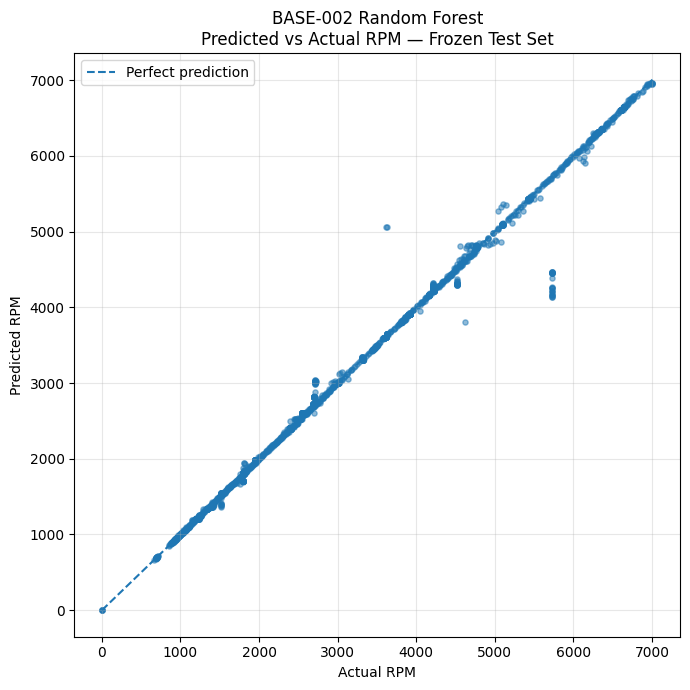

In [31]:
# Step 12 — Generate engineering error-analysis plots
# We want more than one aggregate MAE number

# Step 12A — Predicted versus actual RPM

# ============================================================
# STEP 12A — PREDICTED VS ACTUAL RPM
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 7)
)

ax.scatter(
    test_predictions["rpm_mean"],
    test_predictions["rpm_predicted"],
    s=14,
    alpha=0.5,
)

rpm_min = min(
    test_predictions["rpm_mean"].min(),
    test_predictions["rpm_predicted"].min(),
)

rpm_max = max(
    test_predictions["rpm_mean"].max(),
    test_predictions["rpm_predicted"].max(),
)

ax.plot(
    [rpm_min, rpm_max],
    [rpm_min, rpm_max],
    linestyle="--",
    label="Perfect prediction",
)

ax.set_xlabel(
    "Actual RPM"
)

ax.set_ylabel(
    "Predicted RPM"
)

ax.set_title(
    "BASE-002 Random Forest\n"
    "Predicted vs Actual RPM — Frozen Test Set"
)

ax.legend()

ax.grid(
    True,
    alpha=0.3,
)

fig.tight_layout()

output_path = (
    BASELINE_MODEL_FIGURE_DIR
    / "02_base002_test_predicted_vs_actual.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

# Look for:
  # bias at low/high RPM,
  # compression toward the mean,
  # clusters of large misses,
  # any systematic curvature.

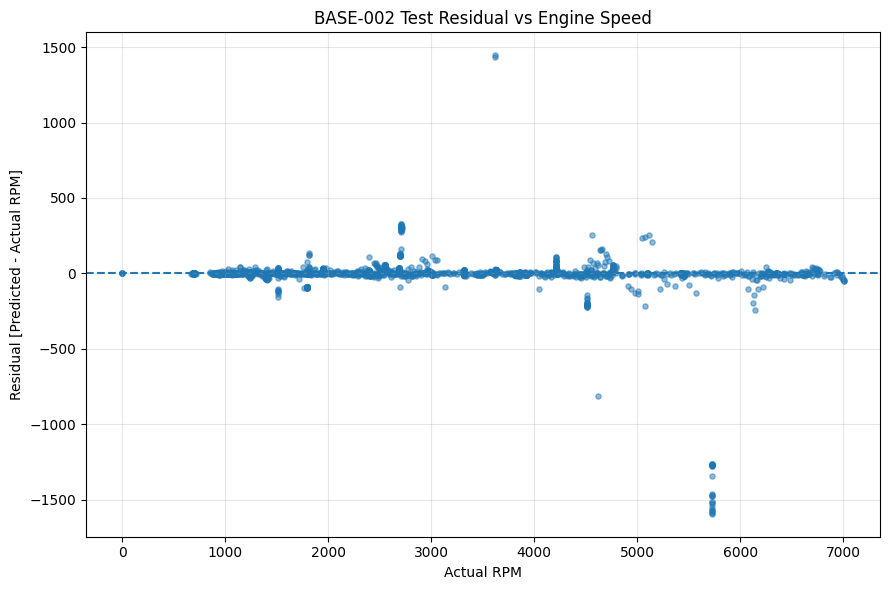

In [32]:
# Step 12B — Residual versus actual RPM
# residual = predicted - actual
# So,
  # positive residual = overprediction
  # negative residual = underprediction

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    test_predictions["rpm_mean"],
    test_predictions["residual_rpm"],
    s=14,
    alpha=0.5,
)

ax.axhline(
    0,
    linestyle="--",
)

ax.set_xlabel(
    "Actual RPM"
)

ax.set_ylabel(
    "Residual [Predicted - Actual RPM]"
)

ax.set_title(
    "BASE-002 Test Residual vs Engine Speed"
)

ax.grid(
    True,
    alpha=0.3,
)

fig.tight_layout()

output_path = (
    BASELINE_MODEL_FIGURE_DIR
    / "03_base002_test_residual_vs_rpm.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

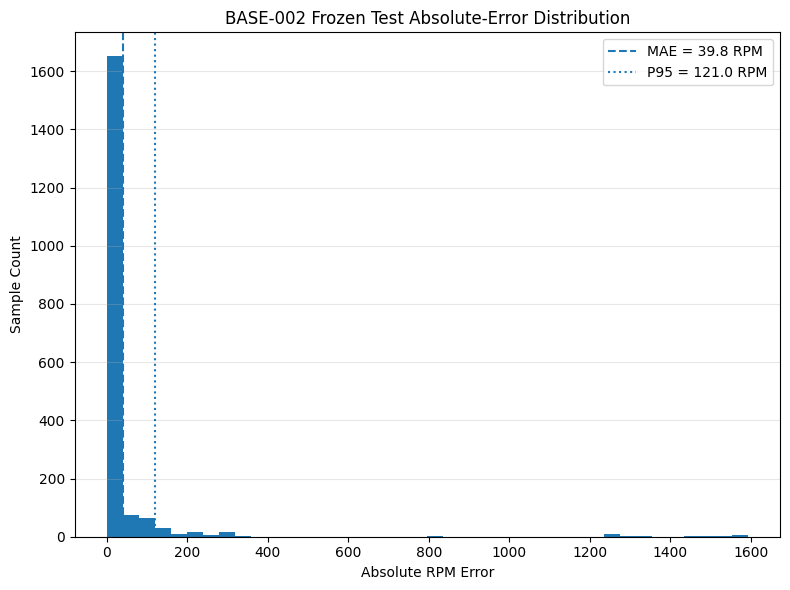

In [33]:
# Step 12C — Absolute-error distribution

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.hist(
    test_predictions[
        "absolute_error_rpm"
    ],
    bins=40,
)

ax.axvline(
    test_metrics["mae_rpm"],
    linestyle="--",
    label=(
        f"MAE = "
        f"{test_metrics['mae_rpm']:.1f} RPM"
    ),
)

ax.axvline(
    test_metrics[
        "p95_absolute_error_rpm"
    ],
    linestyle=":",
    label=(
        f"P95 = "
        f"{test_metrics['p95_absolute_error_rpm']:.1f} RPM"
    ),
)

ax.set_xlabel(
    "Absolute RPM Error"
)

ax.set_ylabel(
    "Sample Count"
)

ax.set_title(
    "BASE-002 Frozen Test "
    "Absolute-Error Distribution"
)

ax.legend()

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

output_path = (
    BASELINE_MODEL_FIGURE_DIR
    / "04_base002_test_absolute_error_distribution.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

In [34]:
# Step 13 — Analyze performance by RPM operating band
# This is more useful for NVH engineering than a single global metric.
# Use training-set quartiles to define the RPM bands.
# That's important—we don't derive the band boundaries from test data.

# ============================================================
# STEP 13 — ERROR BY RPM OPERATING BAND
# ============================================================

rpm_band_edges = np.quantile(
    train_df["rpm_mean"],
    [
        0.00,
        0.25,
        0.50,
        0.75,
        1.00,
    ],
)

rpm_band_edges = np.unique(
    rpm_band_edges
)

print(
    "Training-derived RPM band edges:"
)

print(
    rpm_band_edges
)

Training-derived RPM band edges:
[   0.         1494.46285248 2693.51142248 4289.96467749 6992.08279928]


In [35]:
# Assign bands
test_predictions[
    "rpm_band"
] = pd.cut(
    test_predictions["rpm_mean"],
    bins=rpm_band_edges,
    include_lowest=True,
)

In [36]:
# There may occasionally be a test point just outside the training extrema.
# Check:

outside_band_count = (
    test_predictions[
        "rpm_band"
    ].isna().sum()
)

print(
    "Test samples outside training "
    f"RPM-band envelope: {outside_band_count}"
)

Test samples outside training RPM-band envelope: 5


In [37]:
# Now calculate metrics:

rpm_band_summary = (
    test_predictions
    .dropna(
        subset=["rpm_band"]
    )
    .groupby(
        "rpm_band",
        observed=True,
    )
    .agg(

        samples=(
            "sample_id",
            "count",
        ),

        actual_rpm_mean=(
            "rpm_mean",
            "mean",
        ),

        predicted_rpm_mean=(
            "rpm_predicted",
            "mean",
        ),

        mae_rpm=(
            "absolute_error_rpm",
            "mean",
        ),

        rmse_rpm=(
            "squared_error_rpm2",
            lambda x:
                np.sqrt(
                    np.mean(x)
                ),
        ),

        p95_absolute_error_rpm=(
            "absolute_error_rpm",
            lambda x:
                np.percentile(
                    x,
                    95,
                ),
        ),

        mean_residual_rpm=(
            "residual_rpm",
            "mean",
        ),
    )
    .reset_index()
)

display(
    rpm_band_summary
)

,rpm_band,samples,actual_rpm_mean,predicted_rpm_mean,mae_rpm,rmse_rpm,p95_absolute_error_rpm,mean_residual_rpm
0,"(-0.001, 1494.463]",396,1100.918681,1100.978476,5.791136,10.174472,28.602193,0.059794
1,"(1494.463, 2693.511]",477,2093.971235,2097.502472,20.105145,34.112535,91.617270,3.531237
2,"(2693.511, 4289.965]",530,3523.658035,3550.169508,33.058529,110.725877,121.941282,26.511473
3,"(4289.965, 6992.083]",482,5613.298676,5535.153386,94.555119,318.693794,257.578413,-78.145290


In [38]:
# Save

RPM_BAND_SUMMARY_PATH = (
    BASELINE_MODEL_TABLE_DIR
    / "base002_test_error_by_rpm_band_v001.csv"
)

rpm_band_summary.to_csv(
    RPM_BAND_SUMMARY_PATH,
    index=False,
)

print(
    f"Saved:\n"
    f"{RPM_BAND_SUMMARY_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/results/tables/baseline_models/base002_test_error_by_rpm_band_v001.csv


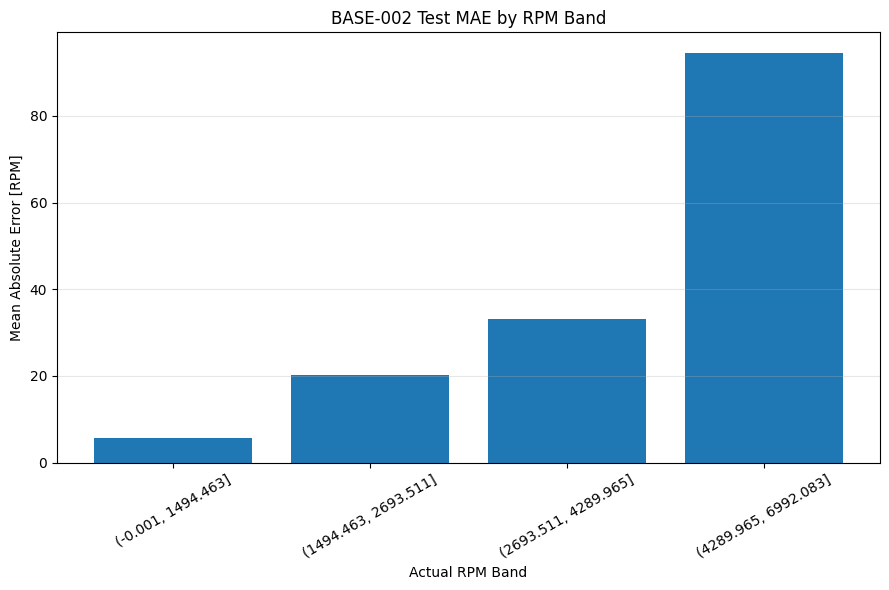

In [39]:
# Plot MAE by band

fig, ax = plt.subplots(
    figsize=(9, 6)
)

band_labels = (
    rpm_band_summary[
        "rpm_band"
    ].astype(str)
)

ax.bar(
    band_labels,
    rpm_band_summary[
        "mae_rpm"
    ],
)

ax.set_xlabel(
    "Actual RPM Band"
)

ax.set_ylabel(
    "Mean Absolute Error [RPM]"
)

ax.set_title(
    "BASE-002 Test MAE by RPM Band"
)

ax.tick_params(
    axis="x",
    rotation=30,
)

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

output_path = (
    BASELINE_MODEL_FIGURE_DIR
    / "05_base002_test_mae_by_rpm_band.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

In [40]:
# Step 14 — Analyze Random-Forest feature importance
# Because BASE-002 is the winner, this is particularly important.

# ============================================================
# STEP 14 — BASE-002 FEATURE IMPORTANCE
# ============================================================

rf_feature_importance = (
    pd.DataFrame(
        {
            "feature":
                FEATURE_COLUMNS,

            "importance":
                best_rf_model.feature_importances_,
        }
    )
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

display(
    rf_feature_importance.head(20)
)

,feature,importance
0,spectral_centroid_hz,0.731674
1,band_energy_1000_2000_hz,0.110422
2,spectral_rolloff_85_hz,0.085196
3,dominant_frequency_hz,0.048135
4,zero_crossing_rate,0.004296
5,mfcc_08_mean,0.003218
6,peak_abs,0.002953
7,mfcc_01_mean,0.002881
8,mfcc_03_mean,0.002240
9,spectral_flatness,0.001298


In [41]:
#.. save
RF_IMPORTANCE_PATH = (
    BASELINE_MODEL_TABLE_DIR
    / "base002_feature_importance_v001.csv"
)

rf_feature_importance.to_csv(
    RF_IMPORTANCE_PATH,
    index=False,
)

print(
    f"Saved:\n"
    f"{RF_IMPORTANCE_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/results/tables/baseline_models/base002_feature_importance_v001.csv


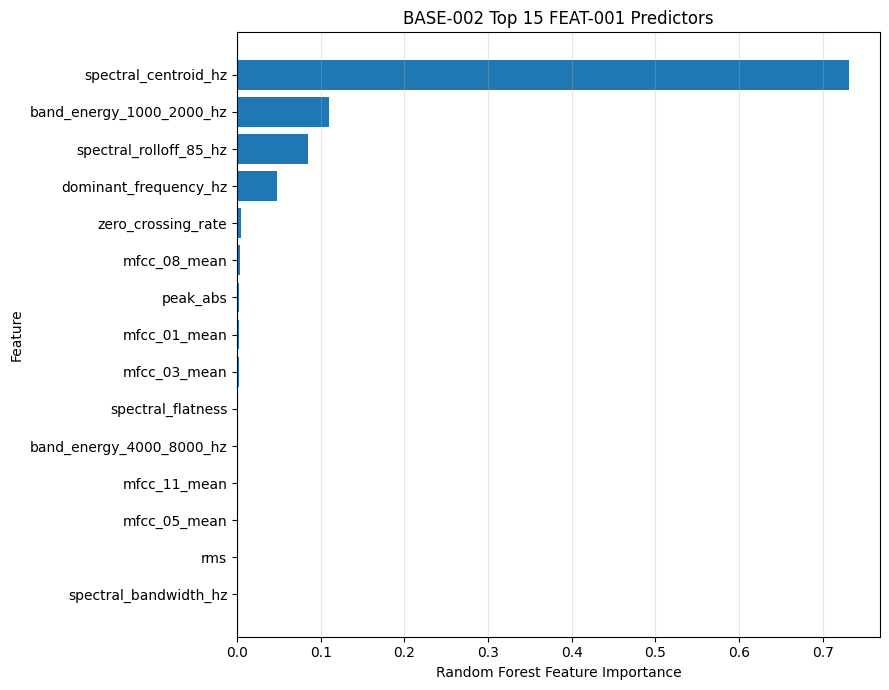

In [42]:
# Plot top-15

top_features = (
    rf_feature_importance
    .head(15)
    .sort_values(
        "importance"
    )
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.barh(
    top_features["feature"],
    top_features["importance"],
)

ax.set_xlabel(
    "Random Forest Feature Importance"
)

ax.set_ylabel(
    "Feature"
)

ax.set_title(
    "BASE-002 Top 15 FEAT-001 Predictors"
)

ax.grid(
    True,
    axis="x",
    alpha=0.3,
)

fig.tight_layout()

output_path = (
    BASELINE_MODEL_FIGURE_DIR
    / "06_base002_feature_importance.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

# Pay particular attention to whether the top predictors are
  # dominant_frequency_hz
  # MFCCs
  # low-frequency band energies
  # spectral centroid/bandwidth
# Those will become useful comparison points when we train the CNN

In [43]:
# Step 15 — Save both trained baseline models
# Even though BASE-002 won, preserve BASE-001 as the linear reference

# ============================================================
# STEP 15 — SAVE BASELINE MODELS TO DRIVE
# ============================================================

import joblib

RIDGE_MODEL_PATH = (
    DRIVE_MODEL_DIR
    / "base001_ridge_rpm_v001.joblib"
)

RF_MODEL_PATH = (
    DRIVE_MODEL_DIR
    / "base002_random_forest_rpm_v001.joblib"
)

joblib.dump(
    best_ridge_model,
    RIDGE_MODEL_PATH,
)

joblib.dump(
    best_rf_model,
    RF_MODEL_PATH,
)

print(
    "BASE-001:"
)

print(
    RIDGE_MODEL_PATH
)

print()

print(
    "BASE-002:"
)

print(
    RF_MODEL_PATH
)

BASE-001:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/models/baseline/base001_ridge_rpm_v001.joblib

BASE-002:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/models/baseline/base002_random_forest_rpm_v001.joblib


In [44]:
# .. Reload both

ridge_model_check = joblib.load(
    RIDGE_MODEL_PATH
)

rf_model_check = joblib.load(
    RF_MODEL_PATH
)

assert np.allclose(
    ridge_model_check.predict(
        X_validation.iloc[:10]
    ),
    best_ridge_model.predict(
        X_validation.iloc[:10]
    ),
)

assert np.allclose(
    rf_model_check.predict(
        X_validation.iloc[:10]
    ),
    best_rf_model.predict(
        X_validation.iloc[:10]
    ),
)

print(
    "PASS: Both baseline models "
    "saved and reloaded successfully."
)

PASS: Both baseline models saved and reloaded successfully.


In [45]:
# Step 16 — Populate experiment_summary.csv
# This is the first time that file becomes meaningful.

# First locate/create it:
# ============================================================
# STEP 16 — UPDATE EXPERIMENT SUMMARY
# ============================================================

import json

EXPERIMENT_SUMMARY_PATH = (
    RESULTS_DIR
    / "experiment_summary.csv"
)

print(
    EXPERIMENT_SUMMARY_PATH
)

# Build BASE-001 row
# BASE-001 must not get test metrics, because it was not selected
base001_row = {

    "experiment_id":
        "BASE-001",

    "model_type":
        "Ridge Regression",

    "target":
        "rpm_mean",

    "preprocessing_version":
        "PREP-001",

    "split_version":
        "SPLIT-001",

    "sample_manifest_version":
        "SAMPLE-MANIFEST-001",

    "order_analysis_version":
        "ORDER-001",

    "feature_version":
        "FEAT-001",

    "training_population":
        "steady_state_only",

    "random_seed":
        42,

    "hyperparameters":
        json.dumps(
            {
                "alpha":
                    BEST_RIDGE_ALPHA,

                "scaler":
                    "StandardScaler",
            }
        ),

    "validation_mae_rpm":
        ridge_validation_metrics[
            "mae_rpm"
        ],

    "validation_rmse_rpm":
        ridge_validation_metrics[
            "rmse_rpm"
        ],

    "validation_r2":
        ridge_validation_metrics[
            "r2"
        ],

    "validation_p95_error_rpm":
        ridge_validation_metrics[
            "p95_absolute_error_rpm"
        ],

    "test_mae_rpm":
        np.nan,

    "test_rmse_rpm":
        np.nan,

    "test_r2":
        np.nan,

    "test_p95_error_rpm":
        np.nan,

    "test_evaluated":
        False,

    "selected_baseline":
        False,
}

# Build BASE-002
best_rf_params = (
    RF_CANDIDATES[
        BEST_RF_INDEX
    ]
)

base002_row = {

    "experiment_id":
        "BASE-002",

    "model_type":
        "Random Forest Regressor",

    "target":
        "rpm_mean",

    "preprocessing_version":
        "PREP-001",

    "split_version":
        "SPLIT-001",

    "sample_manifest_version":
        "SAMPLE-MANIFEST-001",

    "order_analysis_version":
        "ORDER-001",

    "feature_version":
        "FEAT-001",

    "training_population":
        "steady_state_only",

    "random_seed":
        42,

    "hyperparameters":
        json.dumps(
            best_rf_params
        ),

    "validation_mae_rpm":
        rf_validation_metrics[
            "mae_rpm"
        ],

    "validation_rmse_rpm":
        rf_validation_metrics[
            "rmse_rpm"
        ],

    "validation_r2":
        rf_validation_metrics[
            "r2"
        ],

    "validation_p95_error_rpm":
        rf_validation_metrics[
            "p95_absolute_error_rpm"
        ],

    "test_mae_rpm":
        test_metrics[
            "mae_rpm"
        ],

    "test_rmse_rpm":
        test_metrics[
            "rmse_rpm"
        ],

    "test_r2":
        test_metrics[
            "r2"
        ],

    "test_p95_error_rpm":
        test_metrics[
            "p95_absolute_error_rpm"
        ],

    "test_evaluated":
        True,

    "selected_baseline":
        True,
}

# Safely update existing table
new_experiment_rows = pd.DataFrame(
    [
        base001_row,
        base002_row,
    ]
)

if EXPERIMENT_SUMMARY_PATH.exists():

    experiment_summary = pd.read_csv(
        EXPERIMENT_SUMMARY_PATH
    )

    # Remove previous copies if this cell
    # gets rerun.
    experiment_summary = (
        experiment_summary.loc[
            ~experiment_summary[
                "experiment_id"
            ].isin(
                [
                    "BASE-001",
                    "BASE-002",
                ]
            )
        ]
        .copy()
    )

    experiment_summary = pd.concat(
        [
            experiment_summary,
            new_experiment_rows,
        ],
        ignore_index=True,
    )

else:

    experiment_summary = (
        new_experiment_rows.copy()
    )


experiment_summary.to_csv(
    EXPERIMENT_SUMMARY_PATH,
    index=False,
)

display(
    experiment_summary
)

print(
    f"Saved:\n"
    f"{EXPERIMENT_SUMMARY_PATH}"
)

/content/engine-nvh-deep-learning/results/experiment_summary.csv


,experiment_id,model_type,target,preprocessing_version,split_version,sample_manifest_version,order_analysis_version,feature_version,training_population,random_seed,...,validation_mae_rpm,validation_rmse_rpm,validation_r2,validation_p95_error_rpm,test_mae_rpm,test_rmse_rpm,test_r2,test_p95_error_rpm,test_evaluated,selected_baseline
0,BASE-001,Ridge Regression,rpm_mean,PREP-001,SPLIT-001,SAMPLE-MANIFEST-001,ORDER-001,FEAT-001,steady_state_only,42,...,151.467173,201.734227,0.985285,399.019256,NaN,NaN,NaN,NaN,False,False
1,BASE-002,Random Forest Regressor,rpm_mean,PREP-001,SPLIT-001,SAMPLE-MANIFEST-001,ORDER-001,FEAT-001,steady_state_only,42,...,37.617970,127.392182,0.994132,186.703983,39.795796,172.224365,0.990303,120.989312,True,True


Saved:
/content/engine-nvh-deep-learning/results/experiment_summary.csv


In [46]:
# Step 17 — Create the baseline decision report
# Now that you have actual results, create:
# reports/baseline_model_decision_v001.md
# The content captures actual numeric results, not generic statements

# ============================================================
# STEP 17 — CREATE BASELINE MODEL DECISION REPORT
# ============================================================

BASELINE_REPORT_PATH = (
    REPORT_DIR
    / "baseline_model_decision_v001.md"
)

top_5_features = (
    rf_feature_importance
    .head(5)["feature"]
    .tolist()
)

report_text = f"""# Baseline RPM Model Decision — v001

## Objective

The objective of this stage is to establish a reproducible
conventional machine-learning baseline for predicting engine RPM
from one-second acoustic windows before development of the
deep-learning model.

## Modeling lineage

The baseline experiments use the frozen project artifacts:

- PREP-001
- SPLIT-001
- SAMPLE-MANIFEST-001
- ORDER-001
- FEAT-001

Only windows marked as steady-state and eligible under
`model_eligible_rpm_v001` are included in the first RPM model.

## Predictor definition

FEAT-001 contains audio-derived time-domain, spectral,
frequency-band, and MFCC features.

Ground-truth RPM, torque, dataset identifiers, split labels,
and RPM-dependent ORDER-001 features are excluded from the
predictor matrix.

## BASE-001 — Ridge Regression

BASE-001 uses a StandardScaler followed by Ridge regression.

The selected Ridge regularization parameter was:

- alpha = {BEST_RIDGE_ALPHA}

Validation performance:

- MAE = {ridge_validation_metrics['mae_rpm']:.2f} RPM
- RMSE = {ridge_validation_metrics['rmse_rpm']:.2f} RPM
- R² = {ridge_validation_metrics['r2']:.4f}
- P95 absolute error = {ridge_validation_metrics['p95_absolute_error_rpm']:.2f} RPM

## BASE-002 — Random Forest

BASE-002 uses a Random Forest regressor with the validation-selected
configuration:

- n_estimators = {best_rf_params['n_estimators']}
- max_depth = {best_rf_params['max_depth']}
- min_samples_leaf = {best_rf_params['min_samples_leaf']}
- random_state = 42

Validation performance:

- MAE = {rf_validation_metrics['mae_rpm']:.2f} RPM
- RMSE = {rf_validation_metrics['rmse_rpm']:.2f} RPM
- R² = {rf_validation_metrics['r2']:.4f}
- P95 absolute error = {rf_validation_metrics['p95_absolute_error_rpm']:.2f} RPM

## Baseline selection

BASE-002 was selected as the preferred baseline using validation
performance before evaluating the frozen test set.

The Random Forest produced the stronger validation performance and
is therefore designated as the conventional benchmark for subsequent
deep-learning experiments.

## Frozen BASE-002 test performance

After model selection was completed, BASE-002 was evaluated once on
the frozen test split.

Test performance:

- MAE = {test_metrics['mae_rpm']:.2f} RPM
- RMSE = {test_metrics['rmse_rpm']:.2f} RPM
- R² = {test_metrics['r2']:.4f}
- P95 absolute error = {test_metrics['p95_absolute_error_rpm']:.2f} RPM

These test results were not used for additional model tuning.

## Feature importance

The five highest Random Forest feature-importance rankings are:

{chr(10).join(f'- {feature}' for feature in top_5_features)}

Feature importance is interpreted as an indication of which FEAT-001
descriptors were most useful to the Random Forest. It does not by
itself establish physical causality.

## Engineering error analysis

Test errors are additionally evaluated as a function of engine-speed
band using RPM-band boundaries derived from the training population.

This analysis is used to identify operating regions where the
baseline performs comparatively well or poorly without using the
test set for further optimization.

## Limitations

The current model is restricted to steady-state windows from the
procedurally generated A_full_set dataset.

Performance on the frozen test split represents generalization to
unseen source WAV files within this dataset, not generalization to
a different engine, synthesis family, vehicle installation, or
measured production-vehicle recording.

The current feature set also consists of conventional handcrafted
audio descriptors. It does not learn its own time-frequency
representation directly from the acoustic signal.

## Next step

BASE-002 is retained as the conventional RPM-prediction benchmark.

The next stage will develop CNN-001 using a log-mel spectrogram
representation derived from the same PREP-001 model windows.
CNN-001 will be compared against BASE-002 using the same frozen
data split and engineering evaluation metrics.
"""

BASELINE_REPORT_PATH.write_text(
    report_text,
    encoding="utf-8",
)

print(
    f"Saved:\n"
    f"{BASELINE_REPORT_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/reports/baseline_model_decision_v001.md


In [47]:
# Step 18 — Close Notebook 07 cleanly before ending the working
# session for the day

# Saving the notebook directly to GitHub done first.

# 1. Stage the generated Notebook 07 artifacts

# ============================================================
# STAGE NOTEBOOK 07 GITHUB-SIDE ARTIFACTS
# ============================================================

import subprocess

paths_to_add = [
    "reports/baseline_model_decision_v001.md",
    "results/experiment_summary.csv",
    "results/tables/baseline_models",
    "results/figures/baseline_models",
]

existing_paths = [
    path
    for path in paths_to_add
    if (REPO_DIR / path).exists()
]

print("Staging:")

for path in existing_paths:
    print(" +", path)

add_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        *existing_paths,
    ],
    capture_output=True,
    text=True,
)

print(add_result.stdout)

if add_result.stderr:
    print(add_result.stderr)

if add_result.returncode != 0:
    raise RuntimeError(
        "git add failed."
    )

print("PASS: Notebook 07 artifacts staged.")

Staging:
 + reports/baseline_model_decision_v001.md
 + results/experiment_summary.csv
 + results/tables/baseline_models
 + results/figures/baseline_models

PASS: Notebook 07 artifacts staged.


In [48]:
# Check what is staged
status_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--short",
    ],
    capture_output=True,
    text=True,
    check=True,
)

print(status_result.stdout)

A  reports/baseline_model_decision_v001.md
A  results/experiment_summary.csv
A  results/figures/baseline_models/01_rpm_target_distribution.png
A  results/figures/baseline_models/02_base002_test_predicted_vs_actual.png
A  results/figures/baseline_models/03_base002_test_residual_vs_rpm.png
A  results/figures/baseline_models/04_base002_test_absolute_error_distribution.png
A  results/figures/baseline_models/05_base002_test_mae_by_rpm_band.png
A  results/figures/baseline_models/06_base002_feature_importance.png
A  results/tables/baseline_models/base002_feature_importance_v001.csv
A  results/tables/baseline_models/base002_test_error_by_rpm_band_v001.csv
A  results/tables/baseline_models/base002_test_predictions_v001.csv
A  results/tables/baseline_models/baseline_validation_comparison_v001.csv



In [49]:
# 2. Commit the generated artifacts

# ============================================================
# COMMIT NOTEBOOK 07 ARTIFACTS
# ============================================================

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Add BASE-001 and BASE-002 RPM baselines",
    ],
    capture_output=True,
    text=True,
)

print(commit_result.stdout)

if commit_result.stderr:
    print(commit_result.stderr)

combined_output = (
    commit_result.stdout
    + commit_result.stderr
).lower()

if (
    commit_result.returncode != 0
    and
    "nothing to commit" not in combined_output
):
    raise RuntimeError(
        "Git commit failed."
    )

print("PASS: Local baseline artifacts committed.")

[main 787a751] Add BASE-001 and BASE-002 RPM baselines
 12 files changed, 2075 insertions(+)
 create mode 100644 reports/baseline_model_decision_v001.md
 create mode 100644 results/experiment_summary.csv
 create mode 100644 results/figures/baseline_models/01_rpm_target_distribution.png
 create mode 100644 results/figures/baseline_models/02_base002_test_predicted_vs_actual.png
 create mode 100644 results/figures/baseline_models/03_base002_test_residual_vs_rpm.png
 create mode 100644 results/figures/baseline_models/04_base002_test_absolute_error_distribution.png
 create mode 100644 results/figures/baseline_models/05_base002_test_mae_by_rpm_band.png
 create mode 100644 results/figures/baseline_models/06_base002_feature_importance.png
 create mode 100644 results/tables/baseline_models/base002_feature_importance_v001.csv
 create mode 100644 results/tables/baseline_models/base002_test_error_by_rpm_band_v001.csv
 create mode 100644 results/tables/baseline_models/base002_test_predictions_v001.

In [50]:
# 3. Determine the current Git branch

# ============================================================
# DETERMINE CURRENT BRANCH
# ============================================================

current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

print(
    f"Current branch: {current_branch}"
)

Current branch: main


In [51]:
# 4. Pull the notebook commit from GitHub using rebase
# Because you saved 07_baseline_models.ipynb directly to GitHub,
# the remote branch is likely ahead of your local /content clone.

# ============================================================
# RECONCILE DIRECT NOTEBOOK SAVE FROM GITHUB
# ============================================================

pull_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "pull",
        "--rebase",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)

print(pull_result.stdout)

if pull_result.stderr:
    print(pull_result.stderr)

if pull_result.returncode != 0:
    raise RuntimeError(
        "git pull --rebase failed.\n"
        "Do not push until this is resolved."
    )

print(
    "PASS: Local artifact commit rebased "
    "onto current GitHub state."
)


From https://github.com/vaibhavjiyer87/engine-nvh-deep-learning
 * branch            main       -> FETCH_HEAD
   1dc8587..b94e465  main       -> origin/main
Rebasing (1/1)

Successfully rebased and updated refs/heads/main.

PASS: Local artifact commit rebased onto current GitHub state.


In [52]:
# 5. Push everything back to GitHub

# ============================================================
# PUSH RECONCILED NOTEBOOK 07 STATE
# ============================================================

push_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)

print(push_result.stdout)

if push_result.stderr:
    print(push_result.stderr)

if push_result.returncode != 0:
    raise RuntimeError(
        "Git push failed."
    )

print(
    "PASS: Notebook 07 artifacts pushed to GitHub."
)


To https://github.com/vaibhavjiyer87/engine-nvh-deep-learning.git
   b94e465..f5d92e5  main -> main

PASS: Notebook 07 artifacts pushed to GitHub.


In [53]:
# 6. Final synchronization check

# ============================================================
# FINAL LOCAL ↔ GITHUB SYNCHRONIZATION CHECK
# ============================================================

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "fetch",
        "origin",
    ],
    check=True,
)

local_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        "HEAD",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

remote_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        f"origin/{current_branch}",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

print("Local :", local_head)
print("Remote:", remote_head)

assert local_head == remote_head

print(
    "PASS: Local and GitHub HEADs match."
)

Local : f5d92e5b35e1b0dbbfa37d0f92a1e80412ab08d6
Remote: f5d92e5b35e1b0dbbfa37d0f92a1e80412ab08d6
PASS: Local and GitHub HEADs match.


In [54]:
#...then verify the working tree is clean

final_status = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--porcelain",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

if final_status:
    print(
        "WARNING: Uncommitted files remain:"
    )
    print(final_status)

else:
    print(
        "PASS: Working tree is clean."
    )

PASS: Working tree is clean.
